# Classical Shadows on a Cluster State

This notebook is a companion example for the Qurrium paper's classical-shadow
demonstrations. Using `qurrium`, we:

1. Build a 6-qubit cluster state with open boundary condition.
2. Measure it with `ShadowUnveil` using a classical-shadow protocol (randomized single-qubit Pauli measurement bases).
3. Estimate three properties with the measurement outcomes: **mutual information** between two halves of the chain, **observable** expectation values on a subsystem, and (to be added) state **overlap**.


## Setup

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from qurry import ShadowUnveil
from qurry.recipe import cluster as Cluster, ghz as GHZ, trivial_paramagnet as TrivialParamagnet
import time
from qurry.process.classical_shadow import make_evenly_basis
from qiskit import QuantumCircuit
from qurry.qurries.classical_shadow.analysis import SUAnalysis


In [89]:
from qurry import __version__
print("| Using qurrium version:", __version__)


| Using qurrium version: 1.0.0.dev3


## The measurement manager: `ShadowUnveil`

`ShadowUnveil` is qurry's entry point for classical-shadow experiments: it runs
circuits, and stores every experiment (and its later analyses) that we create
from it below.


In [90]:
experiment_shadow = ShadowUnveil()


/Users/anaball/miniconda3/envs/qurv1/lib/python3.12/site-packages/qurry/process/classical_shadow/matrix_calculation.py:64: PostProcessingThirdPartyUnavailableWarning: "JAX is not available, nothing to set. error: No module named 'jax'"
  warnings.warn(


## Building the cluster state circuit

`qurry.recipe.cluster(num_qubits, border_cond=...)` builds a cluster state:
a Hadamard on every qubit, followed by `CZ` gates entangling neighbors.

Note that `border_cond` **defaults to `"period"`** (a ring, with an extra `CZ`
wrapping qubit `n-1` back to qubit `0`). Here we pass `border_cond='open'`
deliberately, to get a linear chain instead.


In [91]:
n = 6
cluster = Cluster(n, border_cond='open')


In [92]:
cluster.draw()


┌───┐      
q_0: ┤ H ├─■────
     ├───┤ │    
q_1: ┤ H ├─■──■─
     ├───┤    │ 
q_2: ┤ H ├─■──■─
     ├───┤ │    
q_3: ┤ H ├─■──■─
     ├───┤    │ 
q_4: ┤ H ├─■──■─
     ├───┤ │    
q_5: ┤ H ├─■────
     └───┘

## Choosing a measurement basis

A classical shadow is built from many snapshots, each measured in a randomly
chosen single-qubit basis per qubit. `make_evenly_basis(num_qubits, duplication)`
gives us a basis set deterministically: it enumerates **all** `3**num_qubits`
basis combinations exactly `duplication` times each, rather than sampling
randomly. This guarantees even coverage of every basis combination, which is
convenient for a small, reproducible example like this one.


In [93]:
even_basis = make_evenly_basis(num_qubits=n, duplication=1)


## Running the shadow measurement

`cluster_shadow.measure(...)` runs one circuit per snapshot in `cluster_basis`
and returns the resulting experiment object directly (no separate lookup step
needed). `shadow_basis_method='RY_RX_RZ'` selects which set of single-qubit
unitaries is used to realize each basis choice.


In [94]:
SHOTS=100
cluster_exp = experiment_shadow.measure(
    cluster,
    random_basis=even_basis,
    shots=SHOTS,
    tags=('cluster',),
    run_args={'seed_simulator': 42}
)  # FakeBackend, default is Aer


## Analysis

With the shadow measurement in hand, we look at it three ways: the mutual
information between two halves of the chain, expectation values of chosen
observables on a subsystem, and (to be added) the overlap with a reference
state.


### 1. Mutual information

We call `.analyze(...)` three times, on subsystem A (`[0,1]`), subsystem B (`[2,3,4,5]`), and the full chain, then combine `results["purity"]["entropy"]` from each via `I(A:B) = S_A + S_B - S_AB`.


In [95]:
subA = cluster_exp.analyze(selected_qubits=[0, 1])
subB = cluster_exp.analyze(selected_qubits=[2, 3, 4, 5])
full = cluster_exp.analyze(selected_qubits=list(range(n)))


In [96]:
sA = subA.export()['results']['purity']['entropy']
sB = subB.export()['results']['purity']['entropy']
sAB = full.export()['results']['purity']['entropy']
mutual = sA + sB - sAB
print(f"sA={sA}\nsB={sB}\nsAB={sAB}\nsA+sB-sAB={mutual}\n")


sA=1.0001075558844978
sB=1.003765849767909
sAB=0.0001253802230406088
sA+sB-sAB=2.003748025429366



### 2. Observables

Here we instead pass `given_operators` to `.analyze(...)` to get shadow-estimated
expectation values for specific operators on a 3-qubit subsystem, and skip the
(unneeded here) purity/entropy computation with `trace_method="skip_trace"`.


In [97]:
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])


In [98]:
ops = [
    np.kron(I, np.kron(Z, X)),
    np.kron(Z, np.kron(X, Z)),
    np.kron(I, np.kron(X, Z)),
]
cluster_results = cluster_exp.analyze(
    selected_qubits=[0, 1, 2], given_operators=ops, trace_method="skip_trace"
)


`results_fields()` lists every available `(result_block, field)` pair on the
analysis. From there, values can be pulled out attribute-style
(`cluster_results.results['estimation'].estimate_of_given_operators`) or via
the flat, JSON-serializable `export()` dict (`cluster_results.export()['results']['estimation']['estimate_of_given_operators']`)
— both are shown below and return the same data.


In [99]:
cluster_results.results_fields()


(('basic', 'average_snapshots_rho_list'),
 ('basic', 'classical_registers_actually'),
 ('basic', 'taking_time'),
 ('basic', 'rho_method'),
 ('basic', 'random_basis_data'),
 ('basic', 'mean_of_rho'),
 ('estimation', 'estimate_of_given_operators'),
 ('estimation', 'corresponding_rhos'),
 ('estimation', 'accuracy_prob_comp_delta'),
 ('estimation', 'num_of_estimators_k'),
 ('estimation', 'accuracy_predict_epsilon'),
 ('estimation', 'maximum_shadow_norm'),
 ('estimation', 'epsilon_upperbound'),
 ('estimation', 'shadow_norm_upperbound'),
 ('estimation', 'taking_time'),
 ('estimation', 'estimate_trace_method'))

In [100]:
results = cluster_results.results
results['estimation'].estimate_of_given_operators


[np.complex128(0j), np.complex128(0j), np.complex128(0j)]

In [101]:
cluster_results.export()['results']['estimation']['estimate_of_given_operators']


['0j', '0j', '0j']

In [102]:
meanrho = np.array(cluster_results.export()['results']['basic']['mean_of_rho'], dtype='complex128')

### Sanity check: manual trace verification

As a cross-check, computing `Tr(rho . O)` directly from the shadow-estimated
`mean_of_rho` should match the `estimate_of_given_operators` values above, for
the same three operators, $X_0Z_1I_2$, $Z_0X_1Z_2$, and $Z_0X_1I_2$.


In [103]:
print(
    np.trace(meanrho @ np.kron(I, np.kron(Z, X))),
    np.trace(meanrho @ np.kron(Z, np.kron(X, Z))),
    np.trace(meanrho @ np.kron(I, np.kron(X, Z))),
)

(0.9999999999999996+0j) (0.9999999999999998+0j) (-0.007901234567901178+0j)


### 3. Overlap
#### The overlap between the cluster with periodic boundary condition and three reference states: the all-zero state $|0\rangle^{\otimes n}$, the all-plus state $|+\rangle^{\otimes n}$, and the Greenberger--Horne--Zeilinger (GHZ) state $|\mathrm{GHZ}\rangle = \frac{1}{\sqrt{2}} \left(|0\rangle^{\otimes n} + |1\rangle^{\otimes n}\right)$.

First, we show how to estimate the overlap between the shadow-estimated state and an analytical reference state, e.g. `f_{sigma}=Tr(rho @ sigma)`.

In [104]:
def ref_analytical_density_matrix(n,k, kind):
    if kind == 'ghz':
        psi = np.zeros(2**n, dtype='complex128')
        psi[0] = psi[-1] = 1/np.sqrt(2)
        psi_mat = psi.reshape(2**(n - k), 2**k)
        return psi_mat.T @ psi_mat.conj()
    elif kind == 'all-plus':
        psi = np.ones(2**k, dtype='complex128') / np.sqrt(2**k)
        return np.outer(psi, psi.conj())
    elif kind == 'all-zero':
        psi = np.zeros(2**k, dtype='complex128')
        psi[0] = 1.0
        return np.outer(psi, psi.conj())

`ref_analytical_density_matrix(n, k, kind)` builds the *analytic* $k$-qubit reference density matrix $\sigma_k$ for each `kind`:

- `'all-zero'` and `'all-plus'` are already product states, so their $k$-qubit reduced state is just the $k$-qubit version of that product state directly — no real partial trace is needed.
- `'ghz'` is genuinely entangled across all $n$ qubits, so we build the full $n$-qubit GHZ vector and *partially trace it down* to $k$ qubits via the `reshape` / `psi_mat.T @ psi_mat.conj()` trick. Because GHZ is symmetric under any permutation of its qubits, tracing out *any* $n-k$ qubits gives the same reduced state — so it's fine that this traces out the *last* $n-k$ qubits, even though we'll select the *first* $k$ qubits of the cluster state below.

In [105]:
cluster_p = Cluster(n, border_cond='period')
cluster_p_exp = experiment_shadow.measure(
    cluster_p,
    random_basis=even_basis,
    shots=SHOTS,
    tags=('cluster_p',),
    run_args={'seed_simulator': 42}
)  # FakeBackend, default is Aer



Overlap is computed against a **periodic** cluster state (`border_cond='period'`, a ring) rather than the open chain used earlier, so we build `cluster_p` and measure it as its own experiment `cluster_p_exp`, reusing the same `even_basis` / `SHOTS` / seed as the rest of the notebook for consistency.

In [106]:
def compute_trace_linear(clusterrho, matchstate, n, k):
    refrho=ref_analytical_density_matrix(n,k,matchstate)
    return np.trace(clusterrho @ refrho)

`compute_tr_linear` wraps `ref_analytical_density_matrix` and returns $\mathrm{Tr}(\rho_k\,\sigma_k)$ for a given reference `kind`. In the loop below, for each subsystem size $k=1,\dots,n$ we take the shadow-estimated reduced density matrix of the periodic cluster state on qubits $[0, k)$ (`mean_of_rho`, via `trace_method="skip_trace"` since purity/entropy aren't needed here) and compute its overlap with all three analytic references.

Because $\sigma_k$ is a *known, fixed* operator, $\mathrm{Tr}(\rho_k \sigma_k)$ is a **linear functional** of $\rho_k$ — exactly like the observable expectation values in the previous section — so it can be estimated directly from the averaged shadow `mean_of_rho`, with no extra cross-snapshot machinery needed.

In [107]:
overlap_ghz = []
overlap_zero = []
overlap_plus = []
for k in range(1, n + 1):
    cluster_p_results = cluster_p_exp.analyze(
        selected_qubits=range(k), trace_method="skip_trace")
    meanrho_p = np.array(cluster_p_results.export()['results']['basic']['mean_of_rho'], dtype='complex128')
    overlap_ghz.append(compute_trace_linear(meanrho_p, 'ghz', n, k).real)
    overlap_zero.append(compute_trace_linear(meanrho_p, 'all-zero', n, k).real)
    overlap_plus.append(compute_trace_linear(meanrho_p, 'all-plus', n, k).real)
    print(k, overlap_ghz[-1], overlap_zero[-1], overlap_plus[-1])

1 0.49999999999999983 0.49893004115226347 0.5018106995884772
2 0.25358024691358017 0.2509259259259259 0.24882716049382708
3 0.12672839506172837 0.12061728395061723 0.12834362139917688
4 0.0650771604938271 0.06201646090534977 0.06532407407407403
5 0.03312499999999995 0.032615740740740695 0.06499485596707809
6 0.03880401234567897 0.016121399176954713 0.06181198559670774


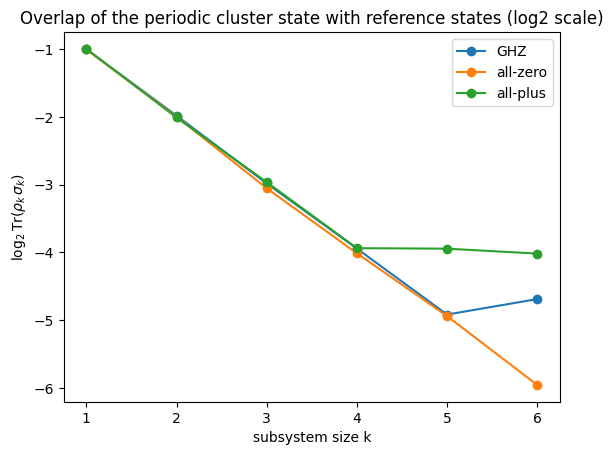

In [108]:
ks = list(range(1, n + 1))
plt.plot(ks, np.log2(overlap_ghz), marker='o', label='GHZ')
plt.plot(ks, np.log2(overlap_zero), marker='o', label='all-zero')
plt.plot(ks, np.log2(overlap_plus), marker='o', label='all-plus')
plt.xlabel('subsystem size k')
plt.ylabel(r'$\log_2 \mathrm{Tr}(\rho_k\,\sigma_k)$')
plt.title('Overlap of the periodic cluster state with reference states (log2 scale)')
plt.legend()
plt.show()

### Cross-shadow overlap: a nonlinear estimator

The approach above only works because we know $\sigma_k$ analytically ahead of time. If instead we only have *another experiment's* classical shadow of the reference state — no closed-form density matrix — then $\mathrm{Tr}(\rho\,\sigma)$ becomes a **nonlinear functional** of the raw shadow data: it requires multiplying per-snapshot estimators from the *two independent* experiments using the same Pauli measurement setting. 

In [109]:
from projector_rho import custom_mean_rho, MY_METHOD_KEY

This pulls in a small custom helper module, `projector_rho.py`, which must be importable alongside this notebook (e.g. on the same path or on `PYTHONPATH`). The reconstruction the projector is given by `custom_mean_rho` routine used below via the argument `rho_method=MY_METHOD_KEY`.

In [118]:
ghz = GHZ(n)
plus = TrivialParamagnet(n)
zero = QuantumCircuit(n)
ghzexp = experiment_shadow.measure(ghz, random_basis=even_basis, shots=2*SHOTS, tags=('ghz',),run_args={'seed_simulator': 42})
plusexp = experiment_shadow.measure(plus, random_basis=even_basis, shots=2*SHOTS, tags=('para',),run_args={'seed_simulator': 42})
zeroexp = experiment_shadow.measure(zero,random_basis=even_basis, shots=2*SHOTS, tags=('init',),run_args={'seed_simulator': 42})


We prepare and measure three reference states directly, using classical shadows exactly like the cluster state: `GHZ(n)` (the GHZ state), `TrivialParamagnet(n)` (an all-`H` circuit, i.e. the all-plus product state $|+\rangle^{\otimes n}$), and a bare `QuantumCircuit(n)` (no gates, i.e. the all-zero product state $|0\rangle^{\otimes n}$).

Each measurement is performed with the **same** `Pauli measurement setting` as the cluster state.


In [ ]:
def projector_custom(clusterexp, matchana, k, n):
    analyze_args = {
        "selected_qubits": list(range(k)),
        "rho_method": MY_METHOD_KEY,
        "trace_method": "skip_trace",
    }
    _, _, postprocess_entries, selected_counts = SUAnalysis.generate_entries(
        arguments=clusterexp.args,
        commonparams=clusterexp.commons,
        counts=clusterexp.afterwards.counts,
        analyze_arguments=analyze_args,
        random_basis=clusterexp.args.random_basis,
    )
    
    cs_basic = custom_mean_rho(
        shots=clusterexp.commons.shots,
        counts=selected_counts,
        random_basis_array=postprocess_entries.random_basis_array,
        selected_classical_registers=list(range(k)),
        rho_method=MY_METHOD_KEY,
    )
    projector_c_list = np.array(cs_basic['average_snapshots_rho_list'], dtype='complex128')
    rho_m_list = np.array(matchana.export()['results']['basic']['average_snapshots_rho_list'], dtype='complex128')
    Nu = len(rho_c_list)

    trclusterrho = np.einsum('nij,nji->n', np.array(projector_c_list), rho_m_list)
    return trclusterrho.sum() / Nu

`projector_custom` is the cross-shadow overlap estimator: it pulls the *per-snapshot* (only shot-averaged) shadow matrices `average_snapshots_rho_list` from the cluster experiment restricted to qubits $[0,k)$, via the lower-level `SUAnalysis.generate_entries` + `custom_mean_rho` path rather than `.analyze()`, so it can use the custom `MY_METHOD_KEY` reconstruction to construct the projector It multiplies each matched snapshot pair (`Tr(projector_c[i] · rho_m[i])`) and averages over all $N_u$ snapshots.

The loop below repeats this for $k=1,\dots,n$ against all three references, first calling `.analyze(..., trace_method="skip_trace")` on each reference experiment restricted to the same $k$ qubits.

In [119]:
nloverlap_ghz = []
nloverlap_zero = []
nloverlap_plus = []
for k in range(1, n + 1):
    zeroana = zeroexp.analyze(selected_qubits=np.arange(k).tolist(),trace_method="skip_trace")
    plusana = plusexp.analyze(selected_qubits=np.arange(k).tolist(),trace_method="skip_trace")
    ghzana = ghzexp.analyze(selected_qubits=np.arange(k).tolist(),trace_method="skip_trace")
    zerooverlap=projector_custom(clusterexp=cluster_p_exp,matchana=zeroana,k=k,n=n)
    plusoverlap=projector_custom(clusterexp=cluster_p_exp,matchana=plusana,k=k,n=n)
    ghzoverlap=projector_custom(clusterexp=cluster_p_exp,matchana=ghzana,k=k,n=n)
    nloverlap_zero.append(zerooverlap)
    nloverlap_plus.append(plusoverlap)
    nloverlap_ghz.append(ghzoverlap)

/Users/anaball/miniconda3/envs/qurv1/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anaball/miniconda3/envs/qurv1/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


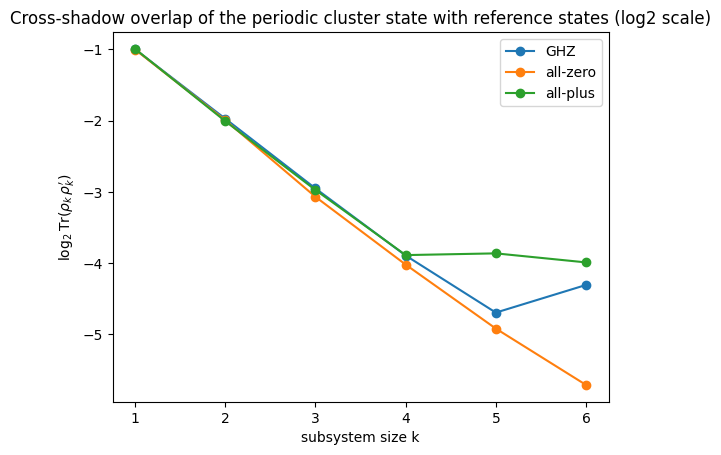

In [120]:
ks = list(range(1, n + 1))
plt.plot(ks, np.log2(nloverlap_ghz), marker='o', label='GHZ')
plt.plot(ks, np.log2(nloverlap_zero), marker='o', label='all-zero')
plt.plot(ks, np.log2(nloverlap_plus), marker='o', label='all-plus')
plt.xlabel('subsystem size k')
plt.ylabel(r'$\log_2 \mathrm{Tr}(\rho_k\,\rho^{\prime}_k)$')
plt.title('Cross-shadow overlap of the periodic cluster state with reference states (log2 scale)')
plt.legend()
plt.show()